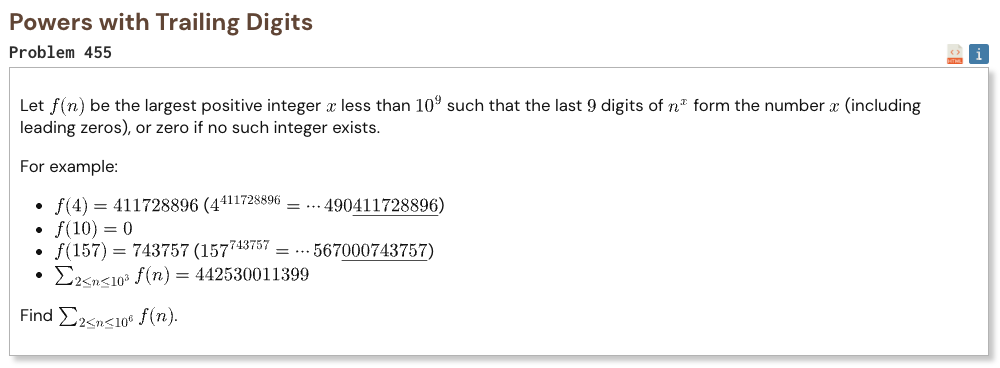

## Initial approach

-   look for a number whose value is equal to its own power result in the last nine digits
-   numbers ending in zero, two, or eight have no valid solution, so their value is zero
-   build the answer one decimal digit at a time instead of searching up to one billion
-   start with the valid last digit and then extend it to two digits, three digits, and so on
-   for each new digit, test the ten possible values from zero to nine
-   reuse one modular power and a multiplier while testing the ten candidates
-   after nine digits, the constructed number is the required fixed point
-   repeat this for every number up to one million and add the results

In [1]:
%%time

LIMIT = 1_000_000

def f(n):
    if n % 10 in (0, 2, 8):
        return 0

    x = 0

    for d in range(1, 10):
        if pow(n, d, 10) == d:
            x = d
            break

    place = 10
    mod = 100

    while mod <= 1_000_000_000:
        value = pow(n, x, mod)
        multiplier = pow(n, place, mod)

        candidate = x

        for d in range(10):
            if value == candidate:
                x = candidate
                break

            candidate += place
            value = value * multiplier % mod

        place *= 10
        mod *= 10

    return x

result = 0

for n in range(2, LIMIT + 1):
    result += f(n)

print("Result:", result)

Result: 299987696199999
CPU times: user 6.68 s, sys: 20.5 ms, total: 6.7 s
Wall time: 6.7 s
